In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from Environment import MCEnv
from estimators import solve_ground_truth,uvn_estimate,wasow_independent,reconciled_reuse_one_long_path ,jacobi_evaluation
from transition_models import gen_reducible_with_absorbing,gen_dense_dirichlet,gen_nearly_deterministic,gen_sparse_neighbor_chain


In [ ]:
n_list = [10,50,100,200,500]
gamma = 0.9
seed0 = 0
start_state = 0

M_list = [100, 300, 1000]     # x-axis for error vs M
N_list = [5, 10]             # horizons for Wasow/Reconciled (use those <= n-ish if you want)

trials = 20                           # repeated independent runs for bias/variance
reward_bound = 1.0                    # rewards in [-reward_bound, reward_bound]

jacobi_tol = 1e-8
jacobi_max_iter = 50_000

In [5]:
P_gen = lambda n, seed: gen_dense_dirichlet(n, alpha=1.0, seed=seed)
# P_gen = lambda n, seed: gen_sparse_neighbor_chain(n, degree=max(3, int(np.sqrt(n))), seed=seed)
# P_gen = lambda n, seed: gen_nearly_deterministic(n, p_main=0.98, seed=seed)
# P_gen = lambda n, seed: gen_reducible_with_absorbing(n, absorb_frac=0.1, seed=seed)

In [4]:
def make_rewards(n: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.uniform(-reward_bound, reward_bound, size=n)

def scalar_stats(estimates: np.ndarray, v_star: float):
    bias = float(np.mean(estimates) - v_star)
    var = float(np.var(estimates, ddof=1)) if len(estimates) >= 2 else 0.0
    mae = float(np.mean(np.abs(estimates - v_star)))
    return bias, var, mae

In [14]:
all_results = {}  

for n in n_list:
    print(f"\n=== n={n} ===")

    # Create instance
    P = P_gen(n, seed0 + 10_000 + n)
    R = make_rewards(n, seed0 + 20_000 + n)

    # Ground truth
    V_star = solve_ground_truth(P, R, gamma)
    v_star_i = float(V_star[start_state])

    # Deterministic baseline (full vector)
    V_jac, iters = jacobi_evaluation(P, R, gamma, tol=jacobi_tol, max_iter=jacobi_max_iter)
    jacobi_mae = float(np.mean(np.abs(V_jac - V_star)))
    jacobi_maxerr = float(np.max(np.abs(V_jac - V_star)))

    # Store curves
    uvn_curve = []
    wasow_grid = []
    rec_grid = []

    # --- UvN: error vs M ---
    print(" Running UvN curve...")
    for M in M_list:
        ests = []
        steps_list = []
        for t in range(trials):
            env = MCEnv(P, R, reward_noise_std=0.1, seed=seed0 + 1000 * n + 100 * M + t)
            est, steps = uvn_estimate(env, i=start_state, M=M, gamma=gamma)
            ests.append(est)
            steps_list.append(steps)

        ests = np.array(ests, dtype=float)
        bias, var, mae = scalar_stats(ests, v_star_i)

        uvn_curve.append(
            {
                "M": M,
                "bias": bias,
                "variance": var,
                "mae_state_i": mae,
                "mean_steps": float(np.mean(steps_list)),
            }
        )

    print(" Running Wasow/Reconciled grid...")
    # --- Wasow / Reconciled: grid over (N, M) ---
    for N in N_list:
        for M in M_list:
            # Wasow (independent fixed-horizon rollouts)
            ests = []
            steps_list = []
            for t in range(trials):
                env = MCEnv(P, R, reward_noise_std=0.1, seed=seed0 + 2000 * n + 1000 * N + 100 * M + t)
                est, steps = wasow_independent(env, i=start_state, M=M, gamma=gamma, N=N)
                ests.append(est)
                steps_list.append(steps)

            ests = np.array(ests, dtype=float)
            bias, var, mae = scalar_stats(ests, v_star_i)

            wasow_grid.append(
                {
                    "N": N,
                    "M": M,
                    "bias": bias,
                    "variance": var,
                    "mae_state_i": mae,
                    "mean_steps": float(np.mean(steps_list)),
                }
            )

            # Reconciled (trajectory reuse procedure; numerically same formula as Wasow with horizon L=N)
            ests = []
            steps_list = []
            for t in range(trials):
                env = MCEnv(P, R, reward_noise_std=0.1, seed=seed0 + 3000 * n + 1000 * N + 100 * M + t)
                est, steps = reconciled_reuse_one_long_path(env, i=start_state, M=M, gamma=gamma, L=N)
                ests.append(est)
                steps_list.append(steps)

            ests = np.array(ests, dtype=float)
            bias, var, mae = scalar_stats(ests, v_star_i)

            rec_grid.append(
                {
                    "L": N,  # horizon
                    "M": M,
                    "bias": bias,
                    "variance": var,
                    "mae_state_i": mae,
                    "mean_steps": float(np.mean(steps_list)),
                }
            )

    all_results[n] = {
        "v_star_i": v_star_i,
        "jacobi": {"iters": iters, "mae_full": jacobi_mae, "maxerr_full": jacobi_maxerr},
        "uvn_curve": uvn_curve,
        "wasow_grid": wasow_grid,
        "rec_grid": rec_grid,
    }
    print(f"Jacobi: iters={iters}, full-MAE={jacobi_mae:.3e}, full-maxerr={jacobi_maxerr:.3e}")




=== n=10 ===
 Running UvN curve...
 Running Wasow/Reconciled grid...
Jacobi: iters=156, full-MAE=8.480e-08, full-maxerr=8.480e-08

=== n=50 ===
 Running UvN curve...
 Running Wasow/Reconciled grid...
Jacobi: iters=158, full-MAE=8.151e-08, full-maxerr=8.151e-08

=== n=100 ===
 Running UvN curve...
 Running Wasow/Reconciled grid...
Jacobi: iters=156, full-MAE=8.164e-08, full-maxerr=8.164e-08

=== n=200 ===
 Running UvN curve...
 Running Wasow/Reconciled grid...
Jacobi: iters=136, full-MAE=8.703e-08, full-maxerr=8.703e-08

=== n=500 ===
 Running UvN curve...
 Running Wasow/Reconciled grid...
Jacobi: iters=137, full-MAE=8.601e-08, full-maxerr=8.601e-08


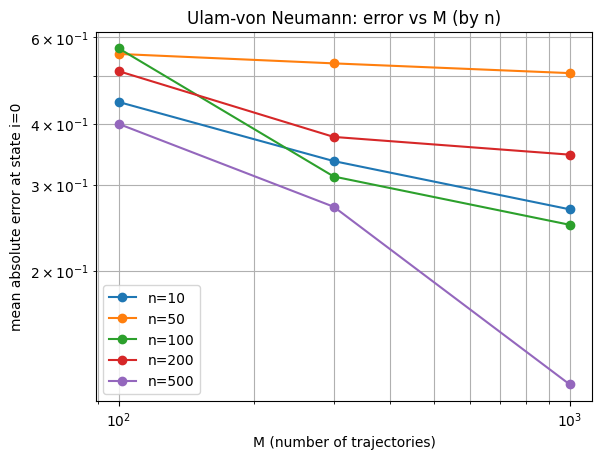

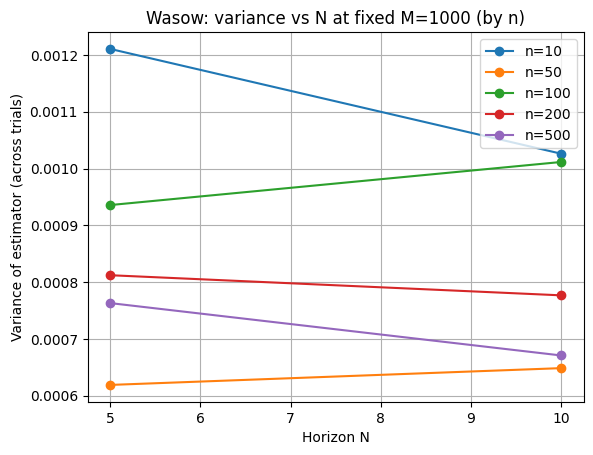

In [16]:
plt.figure()
for n in n_list:
    curve = all_results[n]["uvn_curve"]
    M = [pt["M"] for pt in curve]
    err = [pt["mae_state_i"] for pt in curve]
    plt.plot(M, err, marker="o", label=f"n={n}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("M (number of trajectories)")
plt.ylabel(f"mean absolute error at state i={start_state}")
plt.title("Ulam-von Neumann: error vs M (by n)")
plt.legend()
plt.grid(True, which="both")
plt.show()


# ----------------------------
# Example plots (per n): Bias/Variance vs N for Wasow at fixed M
# ----------------------------
M_fixed = 1000  # choose one from M_list

plt.figure()
for n in n_list:
    grid = [pt for pt in all_results[n]["wasow_grid"] if pt["M"] == M_fixed]
    Ns = sorted(set(pt["N"] for pt in grid))
    bias = [next(pt["bias"] for pt in grid if pt["N"] == N) for N in Ns]
    var = [next(pt["variance"] for pt in grid if pt["N"] == N) for N in Ns]
    # Plot variance only, bias only, or both. Here: variance.
    plt.plot(Ns, var, marker="o", label=f"n={n}")

plt.xlabel("Horizon N")
plt.ylabel("Variance of estimator (across trials)")
plt.title(f"Wasow: variance vs N at fixed M={M_fixed} (by n)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
n_list = [10,50,100]
gamma = 0.9
seed0 = 0
start_state = 0

M_list = [300]     # x-axis for error vs M
N_list = [5, 10,50]             # horizons for Wasow/Reconciled (use those <= n-ish if you want)

trials = 100                           # repeated independent runs for bias/variance
reward_bound = 1.0                    # rewards in [-reward_bound, reward_bound]

jacobi_tol = 1e-8
jacobi_max_iter = 50_000

In [19]:
all_results2 = {}  

for n in n_list:
    print(f"\n=== n={n} ===")

    # Create instance
    P = P_gen(n, seed0 + 10_000 + n)
    R = make_rewards(n, seed0 + 20_000 + n)

    # Ground truth
    V_star = solve_ground_truth(P, R, gamma)
    v_star_i = float(V_star[start_state])

    # Deterministic baseline (full vector)
    V_jac, iters = jacobi_evaluation(P, R, gamma, tol=jacobi_tol, max_iter=jacobi_max_iter)
    jacobi_mae = float(np.mean(np.abs(V_jac - V_star)))
    jacobi_maxerr = float(np.max(np.abs(V_jac - V_star)))

    # Store curves
    uvn_curve = []
    wasow_grid = []
    rec_grid = []

    # --- UvN: error vs M ---
    print(" Running UvN curve...")
    for M in M_list:
        ests = []
        steps_list = []
        for t in range(trials):
            env = MCEnv(P, R, reward_noise_std=0.1, seed=seed0 + 1000 * n + 100 * M + t)
            est, steps = uvn_estimate(env, i=start_state, M=M, gamma=gamma)
            ests.append(est)
            steps_list.append(steps)

        ests = np.array(ests, dtype=float)
        bias, var, mae = scalar_stats(ests, v_star_i)

        uvn_curve.append(
            {
                "M": M,
                "bias": bias,
                "variance": var,
                "mae_state_i": mae,
                "mean_steps": float(np.mean(steps_list)),
            }
        )

    print(" Running Wasow/Reconciled grid...")
    # --- Wasow / Reconciled: grid over (N, M) ---
    for N in N_list:
        for M in M_list:
            # Wasow (independent fixed-horizon rollouts)
            ests = []
            steps_list = []
            for t in range(trials):
                env = MCEnv(P, R, reward_noise_std=0.1, seed=seed0 + 2000 * n + 1000 * N + 100 * M + t)
                est, steps = wasow_independent(env, i=start_state, M=M, gamma=gamma, N=N)
                ests.append(est)
                steps_list.append(steps)

            ests = np.array(ests, dtype=float)
            bias, var, mae = scalar_stats(ests, v_star_i)

            wasow_grid.append(
                {
                    "N": N,
                    "M": M,
                    "bias": bias,
                    "variance": var,
                    "mae_state_i": mae,
                    "mean_steps": float(np.mean(steps_list)),
                }
            )

            # Reconciled (trajectory reuse procedure; numerically same formula as Wasow with horizon L=N)
            ests = []
            steps_list = []
            for t in range(trials):
                env = MCEnv(P, R, reward_noise_std=0.1, seed=seed0 + 3000 * n + 1000 * N + 100 * M + t)
                est, steps = reconciled_reuse_one_long_path(env, i=start_state, M=M, gamma=gamma, L=N)
                ests.append(est)
                steps_list.append(steps)

            ests = np.array(ests, dtype=float)
            bias, var, mae = scalar_stats(ests, v_star_i)

            rec_grid.append(
                {
                    "L": N,  # horizon
                    "M": M,
                    "bias": bias,
                    "variance": var,
                    "mae_state_i": mae,
                    "mean_steps": float(np.mean(steps_list)),
                }
            )

    all_results2[n] = {
        "v_star_i": v_star_i,
        "jacobi": {"iters": iters, "mae_full": jacobi_mae, "maxerr_full": jacobi_maxerr},
        "uvn_curve": uvn_curve,
        "wasow_grid": wasow_grid,
        "rec_grid": rec_grid,
    }
    print(f"Jacobi: iters={iters}, full-MAE={jacobi_mae:.3e}, full-maxerr={jacobi_maxerr:.3e}")




=== n=10 ===
 Running UvN curve...
 Running Wasow/Reconciled grid...
Jacobi: iters=156, full-MAE=8.480e-08, full-maxerr=8.480e-08

=== n=50 ===
 Running UvN curve...
 Running Wasow/Reconciled grid...
Jacobi: iters=158, full-MAE=8.151e-08, full-maxerr=8.151e-08

=== n=100 ===
 Running UvN curve...
 Running Wasow/Reconciled grid...
Jacobi: iters=156, full-MAE=8.164e-08, full-maxerr=8.164e-08


In [20]:
import numpy as np
import matplotlib.pyplot as plt

def _as_arr(xs, key):
    return np.array([d[key] for d in xs], dtype=float)

def _pareto_front(xs, ys):
    # lower envelope in y as x increases
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    best = np.inf
    px, py = [], []
    for x, y in zip(xs, ys):
        if y < best:
            best = y
            px.append(x); py.append(y)
    return np.array(px), np.array(py)

def _collect_points_for_n(res_n):
    # returns list of dicts: method, x=work, y=mae, plus params
    pts = []
    for d in res_n["uvn_curve"]:
        pts.append({"method":"UvN", "work":d["mean_steps"], "mae":d["mae_state_i"], "M":d["M"], "N":np.nan})
    for d in res_n["wasow_grid"]:
        pts.append({"method":"Wasow", "work":d["mean_steps"], "mae":d["mae_state_i"], "M":d["M"], "N":d["N"]})
    for d in res_n["rec_grid"]:
        pts.append({"method":"Reconciled", "work":d["mean_steps"], "mae":d["mae_state_i"], "M":d["M"], "N":d["L"]})
    return pts

def _unique_sorted(vals):
    vals = [v for v in vals if not (isinstance(v,float) and np.isnan(v))]
    return sorted(sorted(set(vals)))


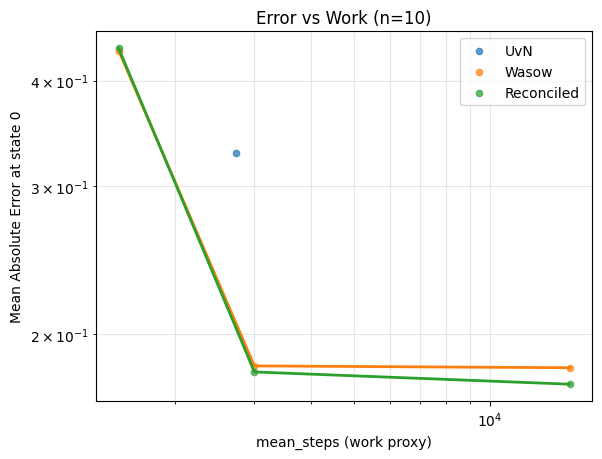

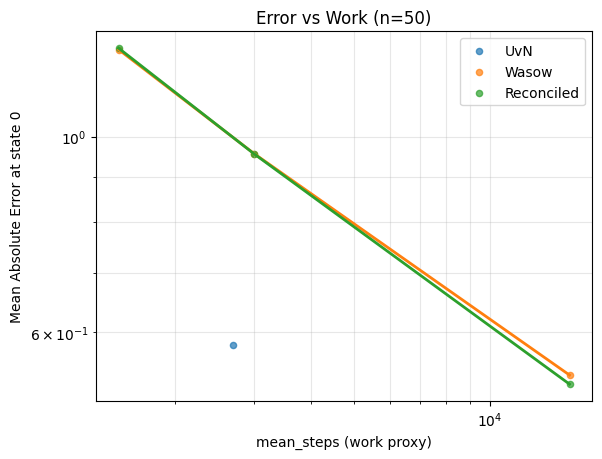

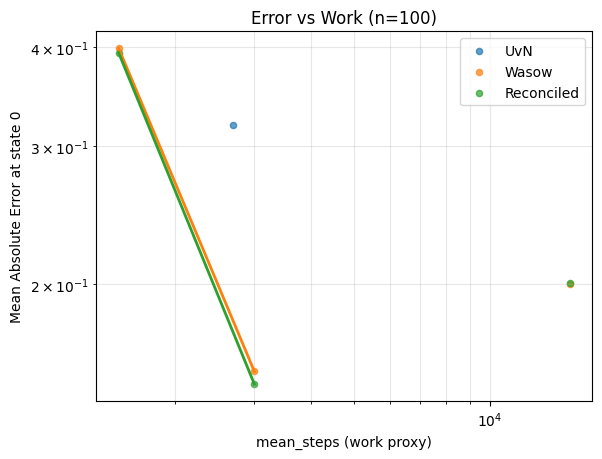

In [24]:
for n, res in all_results2.items():
    pts = _collect_points_for_n(res)
    plt.figure()
    for method in ["UvN","Wasow","Reconciled"]:
        xs = np.array([p["work"] for p in pts if p["method"]==method], float)
        ys = np.array([p["mae"]  for p in pts if p["method"]==method], float)
        plt.scatter(xs, ys, s=20, label=method, alpha=0.7)
        px, py = _pareto_front(xs, ys)
        plt.plot(px, py, linewidth=2)
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("mean_steps (work proxy)")
    plt.ylabel("Mean Absolute Error at state 0")
    plt.title(f"Error vs Work (n={n})")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()


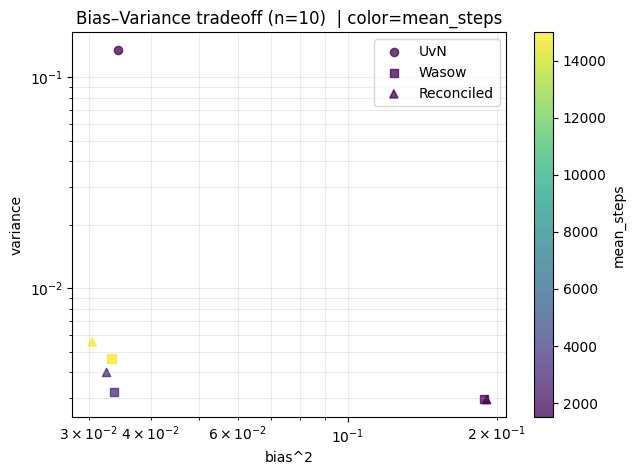

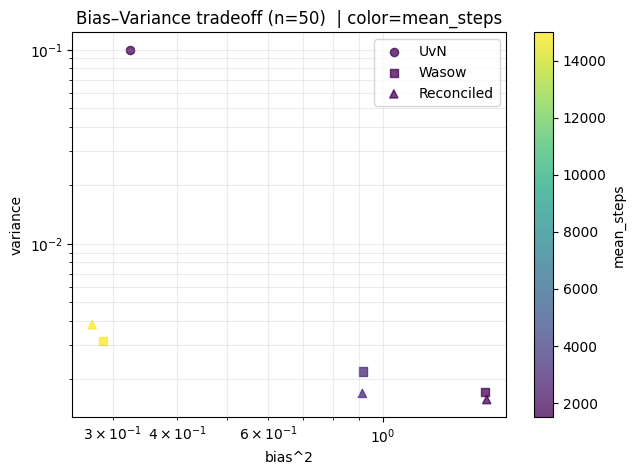

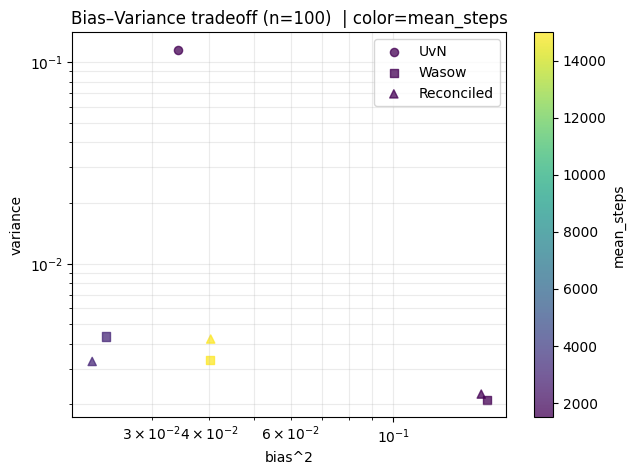

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def _pts_bias_var(res):
    pts = []
    for d in res["uvn_curve"]:
        pts.append(("UvN", d["M"], np.nan, d["bias"], d["variance"], d["mean_steps"]))
    for d in res["wasow_grid"]:
        pts.append(("Wasow", d["M"], d["N"], d["bias"], d["variance"], d["mean_steps"]))
    for d in res["rec_grid"]:
        pts.append(("Reconciled", d["M"], d["L"], d["bias"], d["variance"], d["mean_steps"]))
    return pts

for n, res in all_results2.items():
    pts = _pts_bias_var(res)

    plt.figure(figsize=(7,5))
    for method, marker in [("UvN","o"), ("Wasow","s"), ("Reconciled","^")]:
        sel = [p for p in pts if p[0]==method]
        b2  = np.array([p[3]**2 for p in sel], float)
        v   = np.array([p[4]     for p in sel], float)
        w   = np.array([p[5]     for p in sel], float)

        sc = plt.scatter(b2, v, c=w, s=35, marker=marker, alpha=0.75, label=method)

    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("bias^2")
    plt.ylabel("variance")
    plt.title(f"Bias–Variance tradeoff (n={n})  | color=mean_steps")
    plt.colorbar(sc, label="mean_steps")
    plt.legend()
    plt.grid(True, which="both", alpha=0.25)
    plt.show()


In [29]:
P_gen = lambda n, seed: gen_dense_dirichlet(n, alpha=1.0, seed=seed)
# P_gen = lambda n, seed: gen_sparse_neighbor_chain(n, degree=max(3, int(np.sqrt(n))), seed=seed)
# P_gen = lambda n, seed: gen_nearly_deterministic(n, p_main=0.98, seed=seed)
# P_gen = lambda n, seed: gen_reducible_with_absorbing(n, absorb_frac=0.1, seed=seed)

n_list = [50,100, 200, 500]
gamma = 0.9
seed0 = 0
start_state = 0

M_list = [1000]     # x-axis for error vs M

trials = 30                           # repeated independent runs for bias/variance
reward_bound = 1.0                    # rewards in [-reward_bound, reward_bound]

jacobi_tol = 1e-8
jacobi_max_iter = 50_000


=== n=50 ===
  P#0: Jac iters=153 work=3.825e+05 fullMAE=8.425e-08
  P#1: Jac iters=152 work=3.800e+05 fullMAE=8.381e-08
  P#2: Jac iters=145 work=3.625e+05 fullMAE=8.971e-08
  P#3: Jac iters=148 work=3.700e+05 fullMAE=8.851e-08
  P#4: Jac iters=152 work=3.800e+05 fullMAE=8.907e-08
  P#5: Jac iters=158 work=3.950e+05 fullMAE=8.342e-08
  P#6: Jac iters=144 work=3.600e+05 fullMAE=8.535e-08
  P#7: Jac iters=156 work=3.900e+05 fullMAE=8.695e-08
  P#8: Jac iters=149 work=3.725e+05 fullMAE=8.510e-08
  P#9: Jac iters=122 work=3.050e+05 fullMAE=8.200e-08

=== n=100 ===
  P#0: Jac iters=152 work=1.520e+06 fullMAE=8.514e-08
  P#1: Jac iters=145 work=1.450e+06 fullMAE=8.866e-08
  P#2: Jac iters=153 work=1.530e+06 fullMAE=8.150e-08
  P#3: Jac iters=145 work=1.450e+06 fullMAE=8.189e-08
  P#4: Jac iters=141 work=1.410e+06 fullMAE=8.688e-08
  P#5: Jac iters=122 work=1.220e+06 fullMAE=8.322e-08
  P#6: Jac iters=132 work=1.320e+06 fullMAE=8.972e-08
  P#7: Jac iters=150 work=1.500e+06 fullMAE=8.630e-08

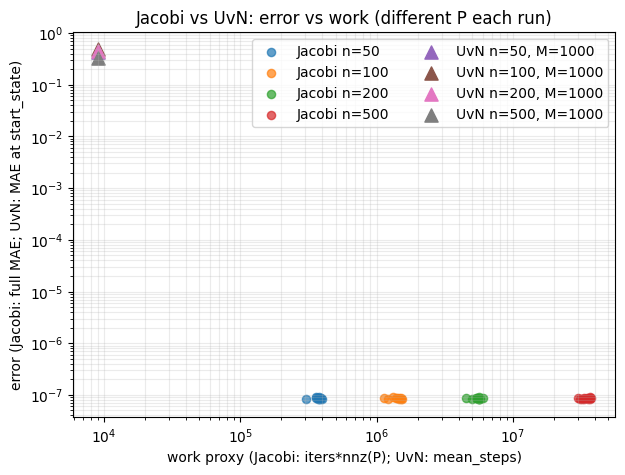

In [30]:

P_trials = 10          # how many different transition matrices per n

def jacobi_work_proxy(P, iters):
    # proxy: iterations × nnz(P) multiplies
    P_arr = np.asarray(P)
    nnz = np.count_nonzero(P_arr)
    return float(iters * nnz)

def run_one_instance(n, seedP, seedR):
    P = P_gen(n, seedP)
    R = make_rewards(n, seedR)  # your function
    V_star = solve_ground_truth(P, R, gamma)
    v_star_i = float(V_star[start_state])

    # Jacobi (full vector)
    V_jac, iters = jacobi_evaluation(P, R, gamma, tol=jacobi_tol, max_iter=jacobi_max_iter)
    jac_mae_full = float(np.mean(np.abs(V_jac - V_star)))
    jac_work = jacobi_work_proxy(P, iters)

    # UvN (state i)
    uvn_rows = []
    for M in M_list:
        ests, steps = [], []
        for t in range(trials):
            env = MCEnv(P, R, reward_noise_std=0.1, seed=seed0 + 1000*n + 100*M + 10_000*t)
            est, st = uvn_estimate(env, i=start_state, M=M, gamma=gamma)
            ests.append(float(est))
            steps.append(float(st))
        ests = np.array(ests)
        bias = float(np.mean(ests) - v_star_i)
        var  = float(np.var(ests, ddof=1))
        mae  = float(np.mean(np.abs(ests - v_star_i)))
        uvn_rows.append({"M": M, "bias": bias, "variance": var, "mae_state_i": mae, "mean_steps": float(np.mean(steps))})

    return {"n": n, "P": P, "R": R, "v_star_i": v_star_i,
            "jacobi": {"iters": iters, "mae_full": jac_mae_full, "work": jac_work},
            "uvn": uvn_rows}

# ----------------------------
# Run: many different P per n
# ----------------------------
results = {}  # results[n] = list of instances
for n in n_list:
    print(f"\n=== n={n} ===")
    instances = []
    for k in range(P_trials):
        seedP = seed0 + 10_000 + 100*n + k
        seedR = seed0 + 20_000 + 100*n + k
        inst = run_one_instance(n, seedP, seedR)
        instances.append(inst)
        print(f"  P#{k}: Jac iters={inst['jacobi']['iters']} work={inst['jacobi']['work']:.3e} fullMAE={inst['jacobi']['mae_full']:.3e}")
    results[n] = instances





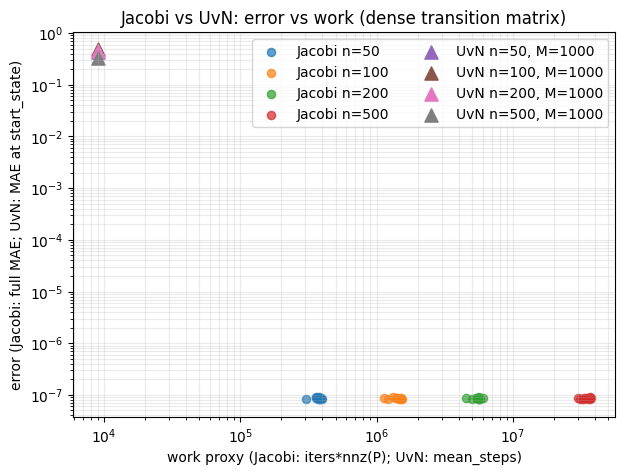

In [33]:
plt.figure(figsize=(7,5))

# Jacobi points (one per P instance)
for n in n_list:
    jac_work = np.array([inst["jacobi"]["work"] for inst in results[n]], float)
    jac_err  = np.array([inst["jacobi"]["mae_full"] for inst in results[n]], float)
    plt.scatter(jac_work, jac_err, s=35, alpha=0.7, label=f"Jacobi n={n}")

# UvN points (avg over P instances; error is state-i MAE)
for n in n_list:
    for M in M_list:
        uvn_work = np.array([next(d for d in inst["uvn"] if d["M"]==M)["mean_steps"] for inst in results[n]], float)
        uvn_err  = np.array([next(d for d in inst["uvn"] if d["M"]==M)["mae_state_i"] for inst in results[n]], float)
        plt.scatter(np.mean(uvn_work), np.mean(uvn_err), marker="^", s=90, label=f"UvN n={n}, M={M}")

plt.xscale("log"); plt.yscale("log")
plt.xlabel("work proxy (Jacobi: iters*nnz(P); UvN: mean_steps)")
plt.ylabel("error (Jacobi: full MAE; UvN: MAE at start_state)")
plt.title("Jacobi vs UvN: error vs work (dense transition matrix)")
plt.grid(True, which="both", alpha=0.25)
plt.legend(ncol=2)
plt.show()

In [36]:
P_gen = lambda n, seed: gen_sparse_neighbor_chain(n, degree=int(np.sqrt(n)), seed=seed)
# P_gen = lambda n, seed: gen_nearly_deterministic(n, p_main=0.98, seed=seed)
# P_gen = lambda n, seed: gen_reducible_with_absorbing(n, absorb_frac=0.1, seed=seed)

n_list = [20,100, 500]
gamma = 0.9
seed0 = 0
start_state = 0

M_list = [2000]     # x-axis for error vs M

reward_bound = 1.0                    # rewards in [-reward_bound, reward_bound]

jacobi_tol = 1e-8
jacobi_max_iter = 50_000

In [37]:

P_trials = 5          # how many different transition matrices per n

def jacobi_work_proxy(P, iters):
    # proxy: iterations × nnz(P) multiplies
    P_arr = np.asarray(P)
    nnz = np.count_nonzero(P_arr)
    return float(iters * nnz)

def run_one_instance(n, seedP, seedR):
    P = P_gen(n, seedP)
    R = make_rewards(n, seedR)  # your function
    V_star = solve_ground_truth(P, R, gamma)
    v_star_i = float(V_star[start_state])

    # Jacobi (full vector)
    V_jac, iters = jacobi_evaluation(P, R, gamma, tol=jacobi_tol, max_iter=jacobi_max_iter)
    jac_mae_full = float(np.mean(np.abs(V_jac - V_star)))
    jac_work = jacobi_work_proxy(P, iters)

    # UvN (state i)
    uvn_rows = []
    for M in M_list:
        ests, steps = [], []
        for t in range(trials):
            env = MCEnv(P, R, reward_noise_std=0.1, seed=seed0 + 1000*n + 100*M + 10_000*t)
            est, st = uvn_estimate(env, i=start_state, M=M, gamma=gamma)
            ests.append(float(est))
            steps.append(float(st))
        ests = np.array(ests)
        bias = float(np.mean(ests) - v_star_i)
        var  = float(np.var(ests, ddof=1))
        mae  = float(np.mean(np.abs(ests - v_star_i)))
        uvn_rows.append({"M": M, "bias": bias, "variance": var, "mae_state_i": mae, "mean_steps": float(np.mean(steps))})

    return {"n": n, "P": P, "R": R, "v_star_i": v_star_i,
            "jacobi": {"iters": iters, "mae_full": jac_mae_full, "work": jac_work},
            "uvn": uvn_rows}

# ----------------------------
# Run: many different P per n
# ----------------------------
results_sparse = {}  # results[n] = list of instances
for n in n_list:
    print(f"\n=== n={n} ===")
    instances = []
    for k in range(P_trials):
        seedP = seed0 + 10_000 + 100*n + k
        seedR = seed0 + 20_000 + 100*n + k
        inst = run_one_instance(n, seedP, seedR)
        instances.append(inst)
        print(f"  P#{k}: Jac iters={inst['jacobi']['iters']} work={inst['jacobi']['work']:.3e} fullMAE={inst['jacobi']['mae_full']:.3e}")
    results_sparse[n] = instances






=== n=20 ===
  P#0: Jac iters=162 work=1.296e+04 fullMAE=8.593e-08
